# Laboratorio Interactivo: Recocido Simulado (Simulated Annealing)

Bienvenidos a esta sesión práctica avanzada de optimización estocástica. En laboratorios previos exploramos heurísticas puramente "avariciosas" (greedy) como el Hill Climbing, constatando su incapacidad para escapar de óptimos locales. Hoy implementaremos el algoritmo de **Recocido Simulado (Simulated Annealing - SA)**, inspirado en la termodinámica estadística, que permite aceptar transitoriamente soluciones peores para escapar de trampas locales.

## 1. Definición del Problema: La Función de Ackley

Evaluaremos nuestro algoritmo sobre la función de Ackley, un *benchmark* diseñado específicamente para frustrar algoritmos de búsqueda local.

**Características:**

* **Embudo Global:** A macroescala, la función converge hacia el centro (gobernado por un término exponencial negativo).
* **Múltiples Óptimos Locales:** A microescala, un término cosenoidal introduce una densa red de crestas y valles.
* **Óptimo global:** Se ubica exactamente en el origen $(0, 0)$, donde $f(0,0) = 0$.

**Fórmula matemática:**


$$f(x, y) = -20 \cdot \exp\left(-0.2 \sqrt{0.5(x^2 + y^2)}\right) - \exp\left(0.5(\cos(2\pi x) + \cos(2\pi y))\right) + 20 + e$$

---

### [Celda de Código 1: Importación de Librerías y Definición Matemática]

In [ ]:
# [PEDAGÓGICO] Importamos librerías estándar para cálculo numérico y visualización interactiva.
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import ipywidgets as widgets
from IPython.display import display, clear_output
import time
import math

# Configuración para gráficos integrados
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

def ackley(x, y):
    """
    Evaluación matemática de la función de Ackley 2D.
    Se vectoriza para permitir el cálculo sobre mallas de matplotlib.
    """
    term1 = -20.0 * np.exp(-0.2 * np.sqrt(0.5 * (x**2 + y**2)))
    term2 = -np.exp(0.5 * (np.cos(2 * np.pi * x) + np.cos(2 * np.pi * y)))
    return term1 + term2 + 20.0 + np.e

# Definición del dominio de exploración
BOUNDS = [-5.0, 5.0]

---

### [Celda de Texto 2: Visualización del Paisaje de Energía]

## 2. Topología del Espacio de Búsqueda

Antes de optimizar, un científico de la computación debe visualizar el paisaje de energía (Energy Landscape). Generaremos una representación estática en 3D y un mapa de contornos en 2D. Observen cómo la superficie está llena de "pozos" engañosos.

---

### [Celda de Código 2: Gráficas Estáticas 2D y 3D]

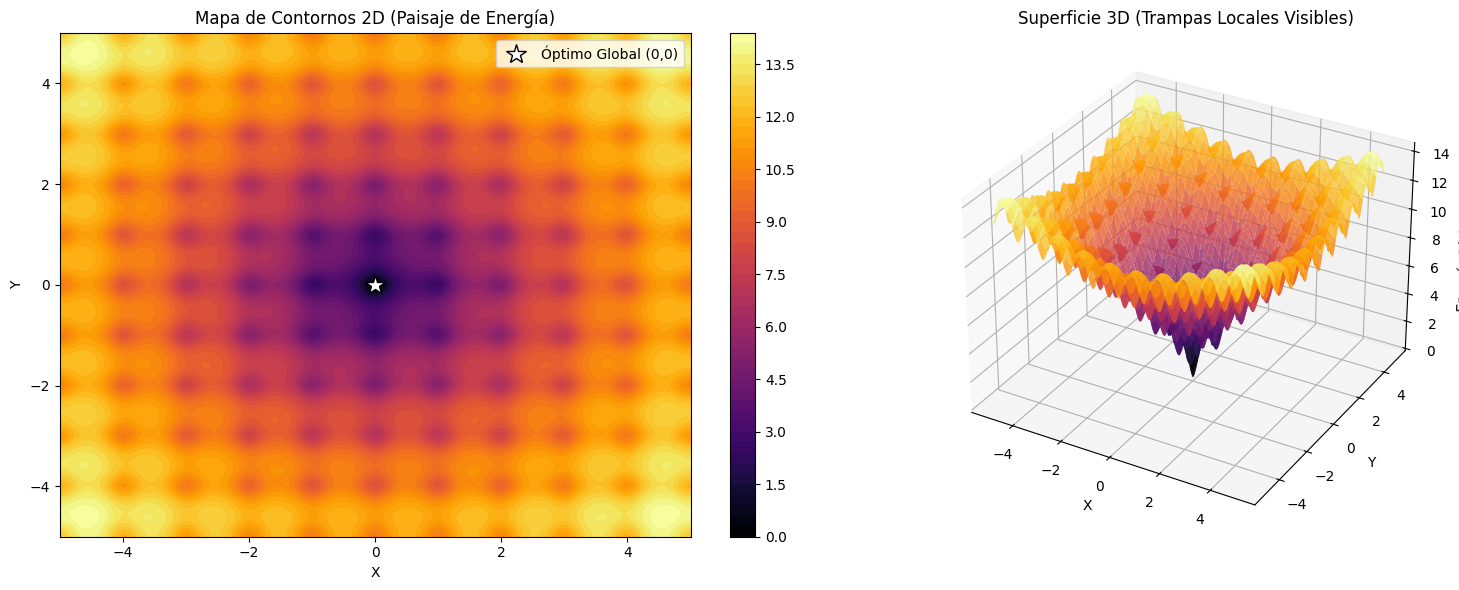

In [ ]:
def plot_ackley_topology():
    """Genera la visualización 2D Contour y 3D Surface de la función de Ackley."""
    x_range = np.linspace(BOUNDS[0], BOUNDS[1], 200)
    y_range = np.linspace(BOUNDS[0], BOUNDS[1], 200)
    X, Y = np.meshgrid(x_range, y_range)
    Z = ackley(X, Y)

    fig = plt.figure(figsize=(16, 6))

    # Gráfica 2D Contour
    ax1 = fig.add_subplot(121)
    contour = ax1.contourf(X, Y, Z, levels=50, cmap='inferno')
    fig.colorbar(contour, ax=ax1)
    ax1.plot(0, 0, 'w*', markersize=15, markeredgecolor='k', label='Óptimo Global (0,0)')
    ax1.set_title('Mapa de Contornos 2D (Paisaje de Energía)')
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.legend()

    # Gráfica 3D Surface
    ax2 = fig.add_subplot(122, projection='3d')
    surf = ax2.plot_surface(X, Y, Z, cmap='inferno', alpha=0.8, edgecolor='none')
    ax2.set_title('Superficie 3D (Trampas Locales Visibles)')
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.set_zlabel('Energía E(s) = f(x,y)')

    plt.tight_layout()
    plt.show()

plot_ackley_topology()

---

### [Celda de Texto 3: Fundamentos de Simulated Annealing]

## 3. Motor Algorítmico: Simulated Annealing

Implementaremos la lógica del algoritmo desde cero.

1. **Estado inicial:** Un vector $\mathbf{s} = (x, y)$ con energía $E(s) = f(x,y)$.
2. **Generación del vecino:** Perturbación aleatoria uniforme $\mathbf{s}' = \mathbf{s} + \mathcal{U}(-\Delta, \Delta)$.
3. **Criterio de Metrópolis:** * Si $\Delta E = E(s') - E(s) < 0$, aceptamos el vecino (es mejor).
* Si $\Delta E \ge 0$, aceptamos con probabilidad $P = \exp\left(-\frac{\Delta E}{T}\right)$.


4. **Esquema de enfriamiento:** Disminución geométrica de la temperatura $T_{k+1} = \alpha \cdot T_k$.

---

### [Celda de Código 3: Clase del Motor de Simulated Annealing]

In [ ]:
class SimulatedAnnealingEngine:
    def __init__(self):
        self.bounds = BOUNDS
        # Variables de registro (logs y trayectorias)
        self.history_accepted = []
        self.history_rejected = []
        self.convergence = []
        self.temp_history = []
        self.prob_history = []
        self.log = []

    def reset(self, x_init, y_init, T0, alpha, step_size):
        """Inicializa los parámetros térmicos y posicionales."""
        self.x = np.clip(x_init, self.bounds[0], self.bounds[1])
        self.y = np.clip(y_init, self.bounds[0], self.bounds[1])
        self.T = max(T0, 1e-5) # Prevenir división por cero
        self.alpha = alpha
        self.step_size = step_size

        self.E_current = ackley(self.x, self.y)
        self.best_E = self.E_current

        # Limpiar historiales
        self.history_accepted = [(self.x, self.y)]
        self.history_rejected = []
        self.convergence = [self.E_current]
        self.temp_history = [self.T]
        self.prob_history = [1.0] # Probabilidad inicial base
        self.log = [f"INICIO: s=({self.x:.2f}, {self.y:.2f}) | E={self.E_current:.4f} | T={self.T:.2f}"]

    def step(self):
        """Ejecuta una iteración (un ciclo térmico)."""
        # 1. Perturbación estocástica (Vecino aleatorio)
        nx = self.x + np.random.uniform(-self.step_size, self.step_size)
        ny = self.y + np.random.uniform(-self.step_size, self.step_size)
        nx = np.clip(nx, self.bounds[0], self.bounds[1])
        ny = np.clip(ny, self.bounds[0], self.bounds[1])

        E_neighbor = ackley(nx, ny)
        delta_E = E_neighbor - self.E_current

        accepted = False
        prob = 0.0

        # 2. Criterio de Aceptación (Metrópolis)
        if delta_E < 0:
            accepted = True
            prob = 1.0
            decision = "ACEPTADO (Mejora estricta)"
        else:
            # [PEDAGÓGICO] Cálculo de la probabilidad de Boltzmann
            prob = math.exp(-delta_E / self.T)
            if np.random.rand() < prob:
                accepted = True
                decision = f"ACEPTADO (Térmico, P={prob:.3f})"
            else:
                decision = f"RECHAZADO (P={prob:.3f})"

        # 3. Actualización de Estados
        log_entry = f"Vecino=({nx:.2f},{ny:.2f}) | ΔE={delta_E:.3f} | T={self.T:.2f} -> {decision}"
        self.log.append(log_entry)

        if accepted:
            self.x, self.y = nx, ny
            self.E_current = E_neighbor
            self.history_accepted.append((self.x, self.y))
            if self.E_current < self.best_E:
                self.best_E = self.E_current
        else:
            self.history_rejected.append((nx, ny))
            self.history_accepted.append((self.x, self.y)) # Mantener el punto actual para gráfica

        # 4. Enfriamiento (Cooling Schedule) y registro de métricas
        self.T *= self.alpha
        self.T = max(self.T, 1e-8) # Límite inferior de temperatura

        self.convergence.append(self.E_current)
        self.temp_history.append(self.T)
        self.prob_history.append(prob)

---

### [Celda de Texto 4: Entorno Visual e Interactivo]

## 4. Visualización Interactiva Total (Dashboard)

Usaremos `ipywidgets` para crear un panel de control.

**Análisis Didáctico Esperado:**

1. **Fase de Exploración (Alta Temperatura):** Al iniciar, la probabilidad $P$ es cercana a $1$. El algoritmo saltará erráticamente entre valles, ignorando incrementos de energía. Notarán marcas de rechazo y aceptación por todo el mapa.
2. **Fase de Explotación (Baja Temperatura):** Conforme $T \to 0$, el algoritmo pierde energía cinética. $P \to 0$ para $\Delta E > 0$. El algoritmo degenera en un Hill Climbing, cayendo hacia el fondo del pozo actual.

---

### [Celda de Código 4: Interfaz Gráfica y Widgets]

In [ ]:
def run_interactive_dashboard():
    engine = SimulatedAnnealingEngine()

    # Malla de fondo para la trayectoria
    X, Y = np.meshgrid(np.linspace(BOUNDS[0], BOUNDS[1], 100),
                       np.linspace(BOUNDS[0], BOUNDS[1], 100))
    Z = ackley(X, Y)

    # Controles Interactivos (Widgets)
    style = {'description_width': 'initial'}
    w_x = widgets.FloatSlider(value=4.0, min=-5.0, max=5.0, step=0.1, description='X Inicial:', style=style)
    w_y = widgets.FloatSlider(value=4.0, min=-5.0, max=5.0, step=0.1, description='Y Inicial:', style=style)
    w_T0 = widgets.FloatLogSlider(value=100.0, base=10, min=0, max=4, step=0.1, description='Temp Inicial (T0):', style=style)
    w_alpha = widgets.FloatSlider(value=0.95, min=0.50, max=0.999, step=0.005, description='Enfriamiento (α):', style=style)
    w_step = widgets.FloatSlider(value=0.5, min=0.05, max=2.0, step=0.05, description='Tamaño de paso:', style=style)

    btn_step = widgets.Button(description='Paso a Paso', button_style='info')
    btn_run = widgets.Button(description='Animar 50 Pasos', button_style='success')
    btn_reset = widgets.Button(description='Reiniciar', button_style='danger')

    out_graphics = widgets.Output()
    out_text = widgets.Output()

    def update_dashboard():
        with out_graphics:
            clear_output(wait=True)
            # Layout de 4 gráficas (2x2)
            fig, axs = plt.subplots(2, 2, figsize=(16, 12))

            # 1. Mapa de Contornos y Trayectoria
            ax_map = axs[0, 0]
            ax_map.contourf(X, Y, Z, levels=40, cmap='inferno')
            ax_map.plot(0, 0, 'w*', markersize=15, label='Óptimo (0,0)')

            # Extraer coordenadas
            ax_x = [p[0] for p in engine.history_accepted]
            ay_y = [p[1] for p in engine.history_accepted]
            rx_x = [p[0] for p in engine.history_rejected]
            ry_y = [p[1] for p in engine.history_rejected]

            ax_map.plot(ax_x, ay_y, 'w-', alpha=0.6, label='Trayectoria')
            ax_map.scatter(rx_x, ry_y, c='red', marker='x', alpha=0.5, label='Rechazados')
            ax_map.scatter(ax_x[-1], ay_y[-1], c='cyan', s=100, edgecolors='k', label='Estado Actual', zorder=5)

            ax_map.set_title("Trayectoria en el Paisaje de Energía")
            ax_map.legend()

            # 2. Curva de Convergencia
            ax_conv = axs[0, 1]
            ax_conv.plot(engine.convergence, 'c-', linewidth=2)
            ax_conv.axhline(0, color='r', linestyle='--')
            ax_conv.set_title(f"Convergencia. Energía actual: {engine.E_current:.4f}")
            ax_conv.set_xlabel("Iteraciones")
            ax_conv.set_ylabel("Energía (Minimizar)")
            ax_conv.grid(True)

            # 3. Decaimiento Térmico
            ax_temp = axs[1, 0]
            ax_temp.plot(engine.temp_history, 'm-', linewidth=2)
            ax_temp.set_yscale('log') # Escala logarítmica para ver el decaimiento claro
            ax_temp.set_title("Evolución de la Temperatura (T)")
            ax_temp.set_xlabel("Iteraciones")
            ax_temp.set_ylabel("Temperatura (Escala Log)")
            ax_temp.grid(True)

            # 4. Probabilidad de Aceptación
            ax_prob = axs[1, 1]
            ax_prob.plot(engine.prob_history, 'g.', alpha=0.5)
            ax_prob.set_title("Probabilidad de Aceptar Peores Soluciones")
            ax_prob.set_xlabel("Iteraciones")
            ax_prob.set_ylabel("Probabilidad P")
            ax_prob.set_ylim(-0.1, 1.1)
            ax_prob.grid(True)

            plt.tight_layout()
            plt.show()

        with out_text:
            clear_output(wait=True)
            print(f"{' ITERACIÓN ':=^80}")
            # Mostrar los últimos 8 registros lógicos
            for log in engine.log[-8:]:
                print(log)

    # Eventos de botones
    def on_reset(b):
        engine.reset(w_x.value, w_y.value, w_T0.value, w_alpha.value, w_step.value)
        update_dashboard()

    def on_step(b):
        engine.step()
        update_dashboard()

    def on_run(b):
        # Deshabilitar botones durante la animación
        btn_run.disabled = True
        btn_step.disabled = True
        for _ in range(50):
            engine.step()
            update_dashboard()
            time.sleep(0.05) # Control de velocidad de animación
        btn_run.disabled = False
        btn_step.disabled = False

    btn_reset.on_click(on_reset)
    btn_step.on_click(on_step)
    btn_run.on_click(on_run)

    # Actualización automática si el usuario mueve sliders iniciales
    w_x.observe(lambda c: on_reset(None), 'value')
    w_y.observe(lambda c: on_reset(None), 'value')

    # Organización de la UI
    ui_controls = widgets.VBox([
        widgets.HBox([w_x, w_y, w_step]),
        widgets.HBox([w_T0, w_alpha]),
        widgets.HBox([btn_step, btn_run, btn_reset])
    ])

    display(ui_controls, out_graphics, out_text)
    on_reset(None) # Ejecución inicial

run_interactive_dashboard()

Output()

Output()

---

### [Celda de Texto 5: Conclusiones y Errores Comunes]

## 5. Explicación Didáctica y Errores de Parametrización (Hyperparameter Tuning)

Si han experimentado con la interfaz interactiva, habrán notado que el éxito de **Simulated Annealing** depende críticamente de sus hiperparámetros. A diferencia de Hill Climbing, que es determinista dado un punto de inicio, SA es altamente sensible a la configuración térmica.

**Errores comunes a evitar (Pruébenlos en la interfaz):**

1. **Enfriamiento muy rápido (Quenching):** Si ajustan $\alpha = 0.50$, la temperatura caerá a cero casi instantáneamente. El algoritmo perderá su energía cinética antes de poder saltar fuera del primer valle local. Matemáticamente, degenera en un Hill Climbing prematuro. Un buen $\alpha$ suele estar entre $0.85$ y $0.99$.
2. **Temperatura inicial insuficiente ($T_0$ muy baja):** Si inician con $T_0 = 0.1$, la probabilidad de aceptar empeoramientos significativos $\exp(-\Delta E / 0.1)$ será prácticamente nula. El algoritmo quedará atrapado desde la iteración 1.
3. **Paso de perturbación inadecuado:** Si el *tamaño de paso* es $0.05$, el algoritmo avanzará micrómetro a micrómetro. Aunque la temperatura le permita subir colinas, requerirá miles de iteraciones para cruzar una cresta de la función de Ackley, volviéndose ineficiente computacionalmente.

**Comparativa Didáctica:**
Simulated Annealing supera a Hill Climbing porque **aprovecha el ruido estocástico para realizar una exploración global** en las primeras etapas, y transiciona fluidamente hacia una **explotación local** en las etapas finales al someterse a la congelación termodinámica.

---